# Proyek Analisis Data: E-commerce-public-dataset
- **Nama:** Tria Amalia Anasya
- **Email:** cdcc409d6x2388@student.devacademy.id
- **ID Dicoding:** CDCC409D6X2388

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Kategori produk apa yang memiliki jumlah penjualan tertinggi selama tahun 2017?
- Pertanyaan 2 : Bagaimana tren total pesanan bulanan selama periode Januari 2017 hingga Agustus 2018?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import datetime as dt
import warnings

from matplotlib.ticker import FuncFormatter
import missingno as msno
import plotly.express as px

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.style.use('seaborn-v0_8')

## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Wrangling

### Gathering Data

Pada tahap ini, dilakukan proses pengumpulan seluruh dataset yang dibutuhkan untuk analisis. Dataset terdiri dari informasi pelanggan, pesanan, detail produk, serta kategori produk yang saling terhubung dalam ekosistem e-commerce.

In [3]:
orders = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/orders_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/customers_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/products_dataset.csv')
sellers = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/sellers_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/order_items_dataset.csv')
payments = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/order_payments_dataset.csv')
reviews = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/order_reviews_dataset.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/geolocation_dataset.csv')
category = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/product_category_name_translation.csv')

**Insight:**
- Dataset terdiri dari beberapa tabel seperti orders, customers, products, dan lainnya yang saling terhubung melalui ID.
- Data bersifat relasional dan mencakup berbagai aspek transaksi e-commerce sehingga perlu digabungkan untuk analisis lebih lanjut.

### Assessing Data

Data yang telah dikumpulkan kemudian diperiksa kualitasnya. Mencakup identifikasi missing values, data duplikat, serta ketidakkonsistenan tipe data (seperti kolom tanggal yang masih terbaca sebagai objek/string)

In [4]:
# Info
orders.info()
customers.info()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null 

In [5]:
# Memeriksa missing values pada dataset
print("Missing values in orders:")
display(orders.isnull().sum())

print("\nMissing values in customers:")
display(customers.isnull().sum())

print("\nMissing values in products:")
display(products.isnull().sum())

Missing values in orders:


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0



Missing values in customers:


,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0



Missing values in products:


,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [6]:
# Memeriksa duplikasi data
print("Duplicate orders:", orders.duplicated().sum())
print("Duplicate customers:", customers.duplicated().sum())

Duplicate orders: 0
Duplicate customers: 0


In [7]:
# Statistik
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight:**
- Pada dataset orders, terdapat missing values yang cukup signifikan pada kolom logistik: order_approved_at (160), order_delivered_carrier_date (1.783), dan order_delivered_customer_date (2.965).
- Pada dataset customers, data sudah bersih (0 missing values).
- Pada dataset products, terdapat 610 baris yang kehilangan informasi nama kategori, deskripsi, dan foto, serta 2 baris yang kehilangan data dimensi produk.
- Tidak ditemukan data duplikat pada dataset orders maupun customers, sehingga integritas data untuk identitas transaksi dan pelanggan terjaga dengan baik.

### Cleaning Data

Setelah dilakukan assesing, tahap pembersihan data dilakukan untuk memastikan akurasi analisis. Langkah yang diambil meliputi mengubah tipe data ke datatime pada kolom waktu, penanganan missing value dengan menginput median, penghapusan data duplikat agar dapat diproses lebih lanjut untuk analisis tren.

In [8]:
# Convert Tipe Data ke datatime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [9]:
# Handle Missing Value dengan median
products['product_weight_g'].fillna(products['product_weight_g'].median(), inplace=True)
products['product_length_cm'].fillna(products['product_length_cm'].median(), inplace=True)
products['product_height_cm'].fillna(products['product_height_cm'].median(), inplace=True)
products['product_width_cm'].fillna(products['product_width_cm'].median(), inplace=True)

# drop kolom yang missingnya banyak
products.dropna(subset=[
    'product_category_name',
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty'
], inplace=True)

**Insight:**
- Tipe data pada kolom timestamp berhasil dikonversi dari object menjadi datetime untuk memudahkan analisis berbasis waktu.
- Missing value telah ditangani menggunakan metode imputasi dan penghapusan data sehingga kualitas data menjadi lebih baik dan siap digunakan.

## Exploratory Data Analysis (EDA)

Tahap EDA dilakukan untuk mengeksplorasi karakteristik data dan mencari pola awal. Analisis mencakup distribusi statistik deskriptif dari variabel penting serta merge antar tabel untuk melihat hubungan antar kriteria, seperti kategori produk terhadap volume penjualan.

### EDA Uniavariate

#### Explore Statistik Deskriptif (Numerikal)

In [10]:
# include="all" agar kolom non numerik juga muncul ringkasannya
print("Statistik Deskriptif - Orders:")
display(orders.describe(include="all"))

print("\nStatistik Deskriptif - Products:")
display(products.describe(include="all"))

print("\nStatistik Deskriptif - Order Items (Harga & Ongkir):")
display(order_items[['price', 'freight_value']].describe())

Statistik Deskriptif - Orders:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00



Statistik Deskriptif - Products:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341,32341,32341.000000,32341.000000,32341.000000,32341.000000,32341.000000,32341.000000,32341.000000
unique,32341,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.907826,30.854364,16.958690,23.208497
std,NaN,NaN,10.245741,635.115225,1.736766,4279.234668,16.955734,13.635922,12.078589
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000



Statistik Deskriptif - Order Items (Harga & Ongkir):


,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


#### Explore Statistik Distribusi (Kategorikal)

In [11]:
print("\nDistribusi Status Pesanan:")
display(orders['order_status'].value_counts())

print("\n10 Kategori Produk yang Paling Banyak Tersedia:")
display(products['product_category_name'].value_counts().head(10))


Distribusi Status Pesanan:


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2



10 Kategori Produk yang Paling Banyak Tersedia:


,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329


### EDA Multivariate

In [12]:
# menggabungkan semua tabel menjadi satu dataframe besar
all_data = pd.merge(order_items, products, on='product_id', how='left')
all_data = pd.merge(all_data, category, on='product_category_name', how='left')
all_data = pd.merge(all_data, orders, on='order_id', how='left')

print("Kolom yang tersedia di all_data:")
print(all_data.columns)

Kolom yang tersedia di all_data:
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date'],
      dtype='object')


In [13]:
# explore korelasi (numerikal vs numerikal)
print("Korelasi antara Harga, Berat, dan Biaya Kirim:")
display(all_data[['price', 'product_weight_g', 'freight_value']].corr())

# explore hubungan (kategorikal vs numerikal)
print("\nRata-rata Harga per Kategori Produk (Top 5):")
display(all_data.groupby('product_category_name_english')['price'].mean().sort_values(ascending=False).head(5))

Korelasi antara Harga, Berat, dan Biaya Kirim:


,price,product_weight_g,freight_value
price,1.000000,0.339817,0.414204
product_weight_g,0.339817,1.000000,0.611343
freight_value,0.414204,0.611343,1.000000



Rata-rata Harga per Kategori Produk (Top 5):


,price
product_category_name_english,
computers,1098.340542
small_appliances_home_oven_and_coffee,624.285658
home_appliances_2,476.124958
agro_industry_and_commerce,342.124858
musical_instruments,281.616000


##

**Insight:**
- Validitas Transaksi: Mayoritas pesanan (97%) berstatus delivered. Artinya data ini valid untuk dianalisis karena sebagian besar transaksi selesai sampai tujuan. Data ini mencakup periode belanja dari 2016 sampai 2018.
- Profil Harga: Rata-rata harga produk berada di angka 120.65. Rentang harga sangat jauh, mulai dari produk sangat murah hingga produk premium di angka 6.735. Kategori Computers menjadi segmen dengan rata-rata harga paling mahal.
- Faktor Ongkir: Biaya kirim sangat dipengaruhi oleh berat produk (korelasi 0.61). Jadi, ongkir lebih ditentukan oleh seberapa berat barangnya daripada seberapa mahal harga barang tersebut.
- Variasi Produk: Kategori perlengkapan rumah tangga (bed_bath_table) dan olahraga (sports_leisure) punya pilihan produk paling banyak di dataset ini, menunjukkan keduanya adalah kategori paling aktif.

## Visualization & Explanatory Analysis

Pada tahap ini, data divisualisasikan untuk menjawab pertanyaan bisnis yang telah saya tetapkan. Visualisasi mencakup analisis kategori produk terlaris di tahun 2017 serta tren pertumbuhan pesanan bulanan untuk periode Januari 2017 hingga Agustus 2018.

### Pertanyaan 1:

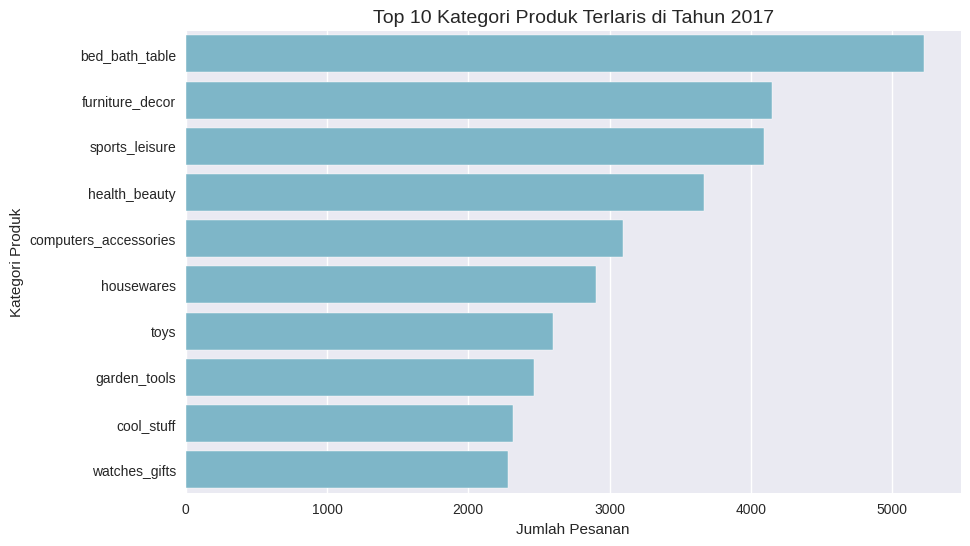

In [21]:
# untuk memastikan format tanggal sudah benar
all_data['order_purchase_timestamp'] = pd.to_datetime(all_data['order_purchase_timestamp'])

# filter data khusus tahun 2017
data_2017 = all_data[all_data['order_purchase_timestamp'].dt.year == 2017]

# saya mengambil 10 kategori terlaris
top_category_2017 = data_2017.groupby('product_category_name_english')['order_id'].count().sort_values(ascending=False).head(10)

# visualisasi bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_category_2017.values, y=top_category_2017.index, color="#72BCD4")
plt.title('Top 10 Kategori Produk Terlaris di Tahun 2017', fontsize=14)
plt.xlabel('Jumlah Pesanan')
plt.ylabel('Kategori Produk')
plt.show()

### Pertanyaan 2:

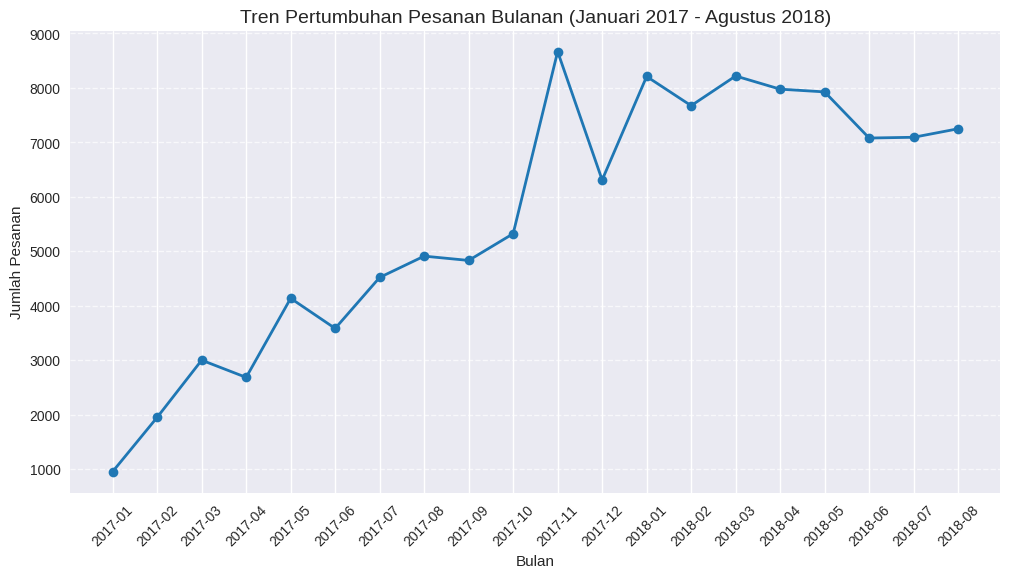

In [15]:
# memastikan kolom tanggal sudah bertipe datetime
all_data['order_purchase_timestamp'] = pd.to_datetime(all_data['order_purchase_timestamp'])

# filter data sesuai pertanyaan bisnis (januari 2017 - agustus 2018)
filtered_monthly_df = all_data[(all_data['order_purchase_timestamp'] >= '2017-01-01') &
                               (all_data['order_purchase_timestamp'] <= '2018-08-31')].copy()

# membuat kolom year-month untuk sumbu X
filtered_monthly_df['month_year'] = filtered_monthly_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# hitung jumlah pesanan per bulan
monthly_orders = filtered_monthly_df.groupby('month_year')['order_id'].count().reset_index()

# visualisasi line chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_orders['month_year'], monthly_orders['order_id'], marker='o', linewidth=2, color='tab:blue')

# judul yang sesuai dengan pertanyaan bisnis
plt.title('Tren Pertumbuhan Pesanan Bulanan (Januari 2017 - Agustus 2018)', fontsize=14)
plt.xlabel('Bulan')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Insight:**
- Pertanyaan 1: Top 10 Kategori Produk Terlaris (2017)
  - Kategori bed_bath_table mendominasi pasar sepanjang tahun 2017 dengan selisih yang cukup jauh dibanding kategori lainnya.
  - Menariknya, tiga besar kategori teratas (bed_bath_table, furniture_decor, dan sports_leisure) semuanya berkaitan dengan kebutuhan rumah tangga dan gaya hidup. Ini menunjukkan bahwa pada tahun 2017, konsumen cenderung lebih banyak menghabiskan uang untuk kenyamanan rumah dan hobi.

- Pertanyaan 2: Tren Pertumbuhan Pesanan Bulanan (2016-2018)
  - Grafik menunjukkan kenaikan pesanan yang sangat konsisten mulai dari awal tahun 2017.
  - Terjadi lonjakan pesanan yang sangat tinggi pada November 2017. Hal ini biasanya merupakan pola musiman e-commerce akibat promo besar
  - Setelah puncak di November 2017, jumlah pesanan cenderung stabil di angka tinggi (di atas 6.000 pesanan per bulan) selama semester pertama 2018, menunjukkan platform ini berhasil mempertahankan pertumbuhan penggunanya.

## Analisis Lanjutan (Opsional)

Terakhir, dilakukan analisis RFM (Recency, Frequency, Monetary) untuk mengelompokkan pelanggan berdasarkan perilaku pembelian mereka. Hal ini bertujuan untuk memberikan wawasan lebih mendalam mengenai loyalitas pelanggan dan segmentasi nilai transaksi tanpa menggunakan algoritma machine learning.

In [17]:
# menentukan tanggal sekarang sebagai referensi (mengambil tanggal terakhir di data + 1 hari)
recent_date = all_data['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# menghitung recency, frequency, dan monetary
rfm_df = all_data.groupby(by="customer_id", as_index=False).agg({
    "order_purchase_timestamp": lambda x: (recent_date - x.max()).days, # Recency
    "order_id": "nunique", # Frequency
    "price": "sum" # Monetary
})

# mengubah nama kolom
rfm_df.columns = ["customer_id", "recency", "frequency", "monetary"]

# saya tampilkan 5 data teratas
print("Hasil RFM Analysis:")
display(rfm_df.head())

Hasil RFM Analysis:


,customer_id,recency,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,293,1,89.80
1,000161a058600d5901f007fab4c27140,414,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,552,1,179.99
3,0002414f95344307404f0ace7a26f1d5,383,1,149.90
4,000379cdec625522490c315e70c7a9fb,154,1,93.00


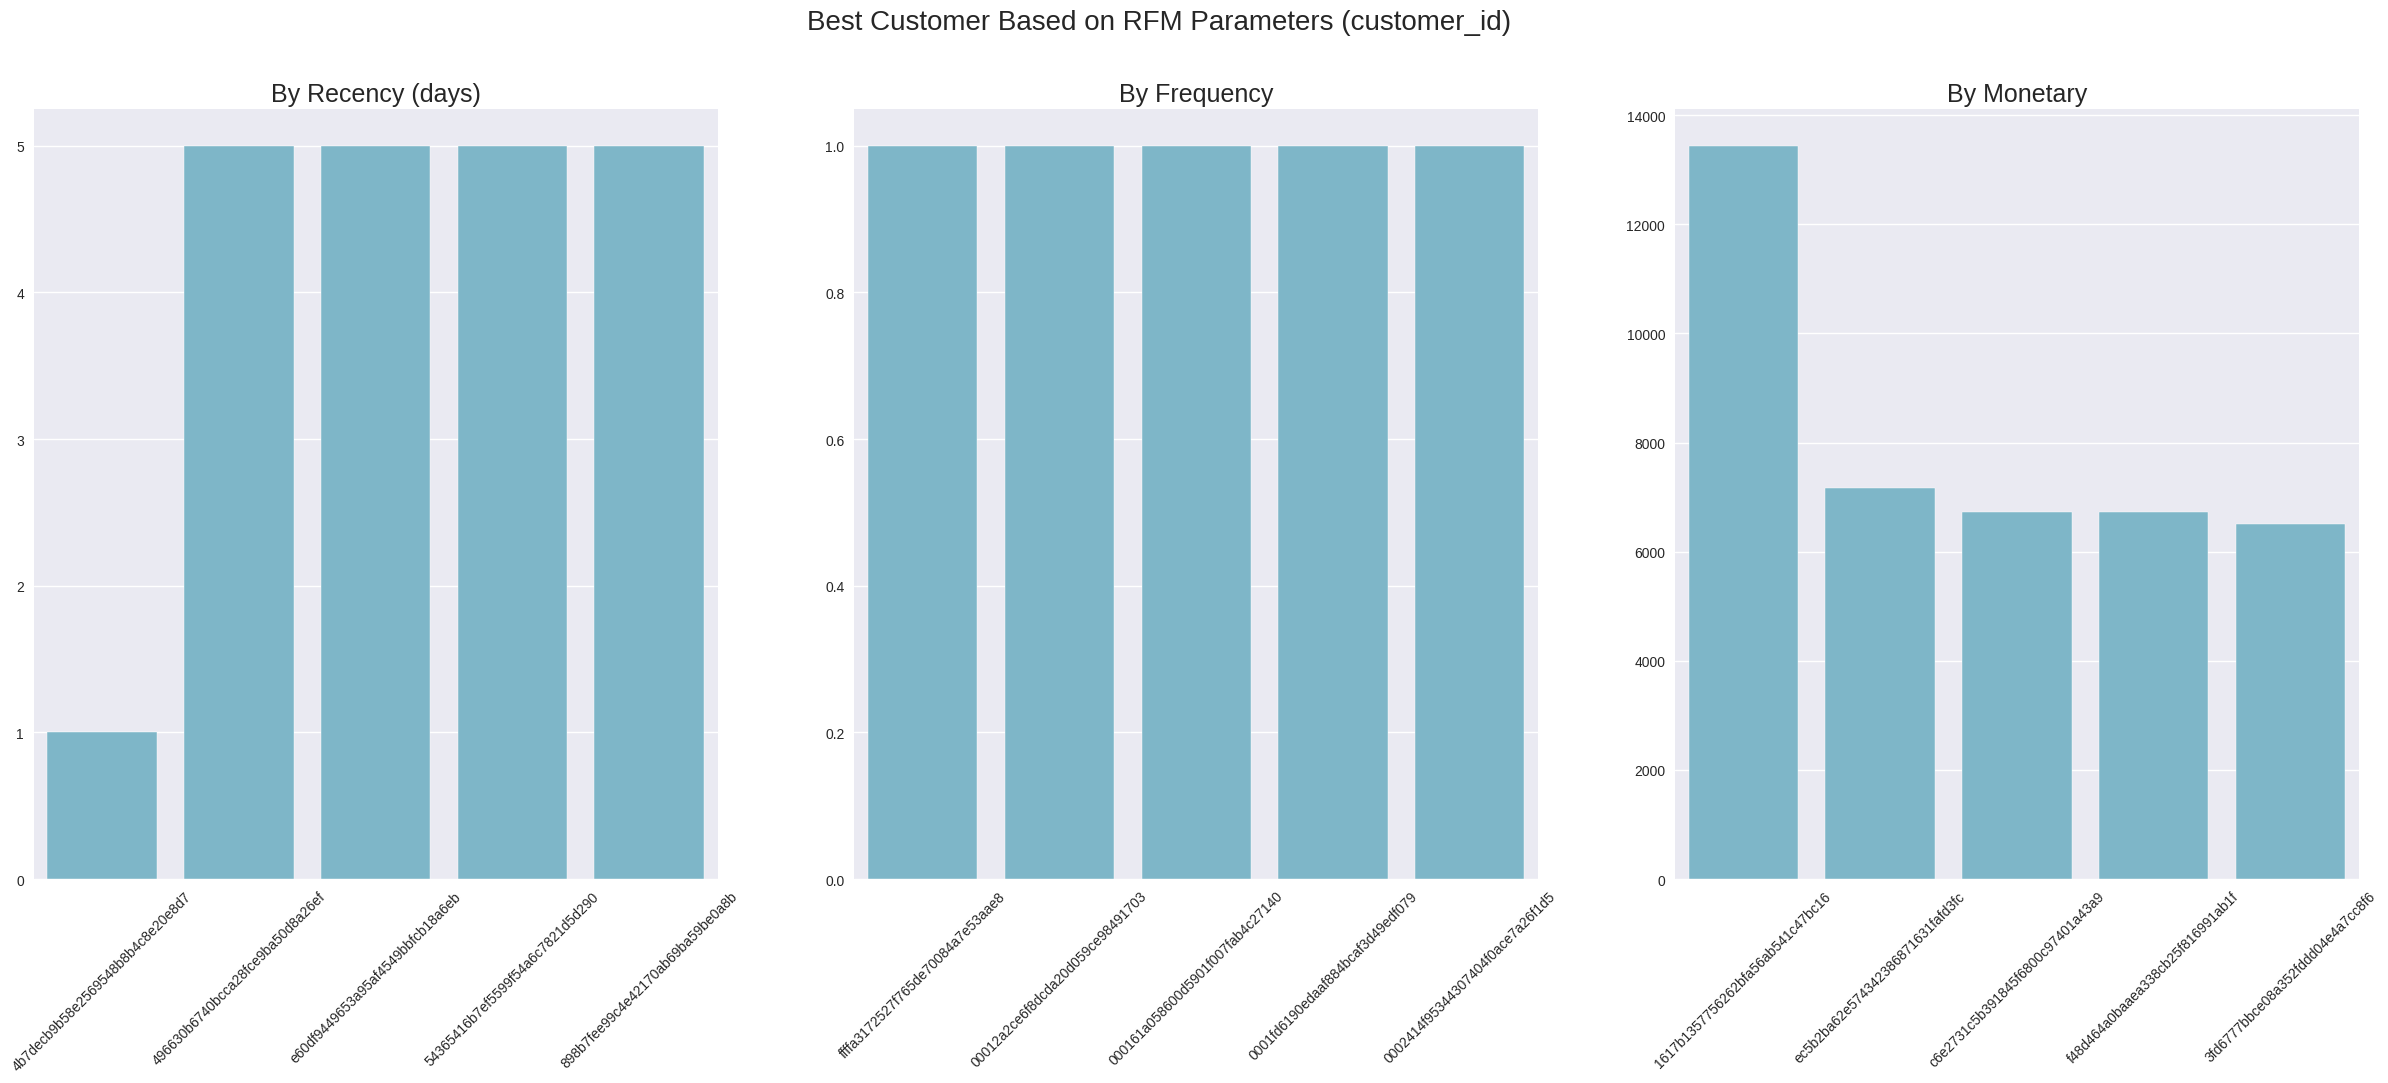

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

# plot berdasarkan recency
sns.barplot(y="recency", x="customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', rotation=45)

# plot berdasarkan frecuency
sns.barplot(y="frequency", x="customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', rotation=45)

# plot berdasarkan monetary
sns.barplot(y="monetary", x="customer_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters (customer_id)", fontsize=20)
plt.show()

Menyimpan file akhir dengan format csv

In [19]:
all_data.to_csv('all_data.csv', index=False)

## Conclusion

- Conclusion Pertanyaan 1: Apa kategori produk yang paling banyak terjual di tahun 2017?
Berdasarkan hasil visualisasi, kategori bed_bath_table merupakan kategori produk yang paling mendominasi pasar pada tahun 2017 dengan jumlah pesanan tertinggi. Diikuti oleh kategori furniture_decor dan sports_leisure. Hal ini mengindikasikan bahwa pada periode tersebut, fokus utama pengeluaran pelanggan adalah pada kebutuhan perlengkapan rumah tangga dan hobi.

- Conclusion Pertanyaan 2: Bagaimana tren pertumbuhan pesanan bulanan dari 2016 sampai 2018?
Tren pesanan menunjukkan pertumbuhan yang sangat signifikan sepanjang tahun 2017, dengan puncak tertinggi terjadi pada bulan November 2017 (bertepatan dengan momen Black Friday). Setelah puncak tersebut, jumlah pesanan cenderung stabil di angka yang lebih tinggi dibandingkan tahun sebelumnya. Namun, perlu dicatat bahwa sebagian besar pelanggan kita saat ini adalah one-time buyers (hanya belanja 1 kali), sehingga dibutuhkan strategi retensi pelanggan yang lebih kuat di masa depan.